In [45]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
train = pd.read_csv('train.csv')

In [6]:
test = pd.read_csv('test.csv')

In [7]:
data = pd.concat([train, test], axis=0, ignore_index=True)

In [8]:
data['fuel_type'].value_counts()

fuel_type
Gasoline          276473
Hybrid             11508
E85 Flex Fuel       8929
Diesel              6641
–                   1319
Plug-In Hybrid       858
not supported         29
Name: count, dtype: int64

In [9]:
data['is_gasoline'] = (data['fuel_type'] == 'Gasoline').astype(int)

In [10]:
data_engine_electric = data[data['fuel_type'].isna()][['engine', 'fuel_type']]

In [11]:
data_engine_electric

,engine,fuel_type
11,Electric Motor Electric Fuel System,NaN
32,518.0HP Electric Motor Electric Fuel System,NaN
51,Dual Motor - Standard,NaN
52,518.0HP Electric Motor Electric Fuel System,NaN
161,670.0HP Electric Motor Electric Fuel System,NaN
...,...,...
313955,835.0HP Electric Motor Electric Fuel System,NaN
314063,271.0HP Electric Motor Electric Fuel System,NaN
314201,518.0HP Electric Motor Electric Fuel System,NaN
314210,Electric Motor Electric Fuel System,NaN


In [31]:
data['Electrical'] = data['engine'].str.contains('Electric', na=False).astype(int)

In [23]:
data['Electrical'].value_counts()

Electrical
0    295678
1     18545
Name: count, dtype: int64

In [26]:
data[data['Electrical'] == 1][['engine', 'fuel_type']].isna().sum()

engine          0
fuel_type    8098
dtype: int64

In [28]:
data.loc[
    (data['fuel_type'].isna()) & (data['Electrical'] == 1),
    'fuel_type'
] = 'Electric'

In [29]:
data['fuel_type'].isna().sum()

368

In [71]:
data[data['fuel_type'].isna()][['engine', 'fuel_type']]

,engine,fuel_type
51,Dual Motor - Standard,NaN
7233,Dual Motor - Standard,NaN
7362,Dual Motor - Standard,NaN
7807,Dual Motor - Standard,NaN
8879,2.0 Liter TFSI,NaN
...,...,...
307920,Dual Motor - Standard,NaN
308824,5.0L V8 32V PDI DOHC,NaN
311266,Dual Motor - Standard,NaN
312319,5.0L V8 32V PDI DOHC,NaN


In [32]:
data['fuel_type'].value_counts()

fuel_type
Gasoline          276473
Hybrid             11508
E85 Flex Fuel       8929
Electric            8098
Diesel              6641
–                   1319
Plug-In Hybrid       858
not supported         29
Name: count, dtype: int64

In [35]:
data.isna().sum()

id                   0
brand                0
model                0
model_year           0
milage               0
fuel_type          368
engine               0
transmission         0
ext_col              0
int_col              0
accident          4084
clean_title      35658
price           125690
is_gasoline          0
Electrical           0
dtype: int64

In [36]:
data.loc[
    (data['fuel_type'].isna()) & (data['engine'].str.contains('Gasoline',case=False,na=False)),
    'fuel_type'
] = 'Gasoline'

In [37]:
data['fuel_type'].isna().sum()

293

In [51]:
data[data['engine'].str.contains('Dual',na=False)][['engine', 'fuel_type']].value_counts()

engine                   fuel_type
Dual Motor - Standard    Gasoline     34
Dual AC Electric Motors  Electric     20
                         Gasoline      6
Dual Motor - Standard    Hybrid        6
                         Diesel        1
Name: count, dtype: int64

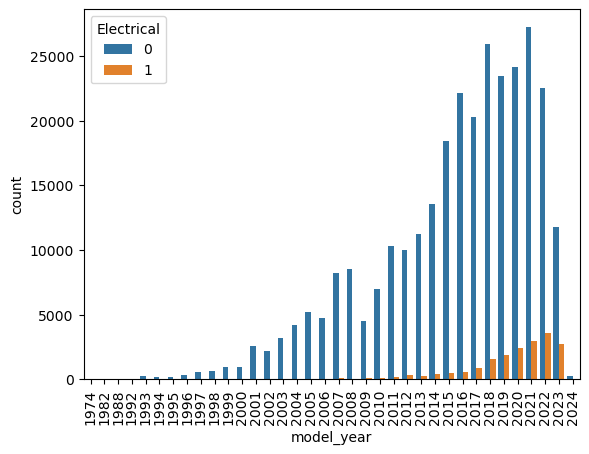

In [46]:
sns.countplot(data=data, x='model_year', hue='Electrical')
plt.xticks(rotation=90)
plt.show()

In [62]:
data[(data['fuel_type'].isna() & data['engine'].str.contains('Diesel', case=False, na=False))][['engine', 'fuel_type']]

,engine,fuel_type
47303,277.0HP 3.0L Straight 6 Cylinder Engine Diesel...,NaN
171080,3.0L I6 24V DDI DOHC Turbo Diesel,NaN
286053,6.7L V8 32V DDI OHV Turbo Diesel,NaN


In [63]:
data.loc[
    (data['fuel_type'].isna()) & (data['engine'].str.contains('Diesel',case=False,na=False)),
    'fuel_type'
] = 'Diesel'

In [75]:
data.loc[
    (data['fuel_type'].isna()),
    'fuel_type'
] = 'Gasoline'

In [76]:
data['fuel_type'].isna().sum()

0

In [79]:
data['accident'].value_counts()

accident
None reported                             240777
At least 1 accident or damage reported     69362
Name: count, dtype: int64

In [80]:
data[['accident', 'clean_title']]

,accident,clean_title
0,None reported,Yes
1,At least 1 accident or damage reported,Yes
2,None reported,Yes
3,None reported,Yes
4,None reported,Yes
...,...,...
314218,None reported,Yes
314219,None reported,NaN
314220,None reported,Yes
314221,None reported,Yes


In [82]:
data['clean_title_filled'] = data['clean_title'].fillna('Unknown')

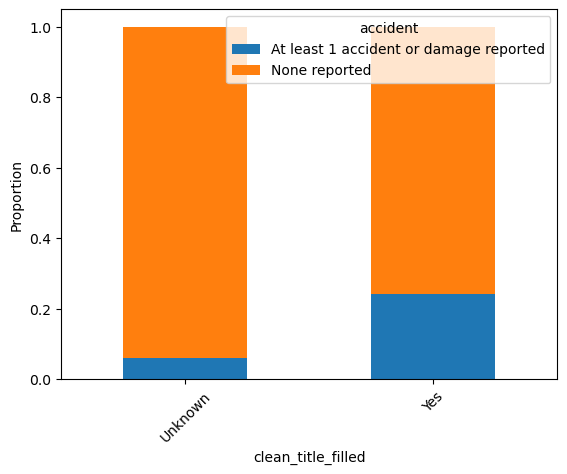

In [84]:
prop = pd.crosstab(
    data['clean_title_filled'],
    data['accident'],
    normalize='index'
)

prop.plot(kind='bar', stacked=True)
plt.ylabel('Proportion')
plt.xticks(rotation=45)
plt.show()

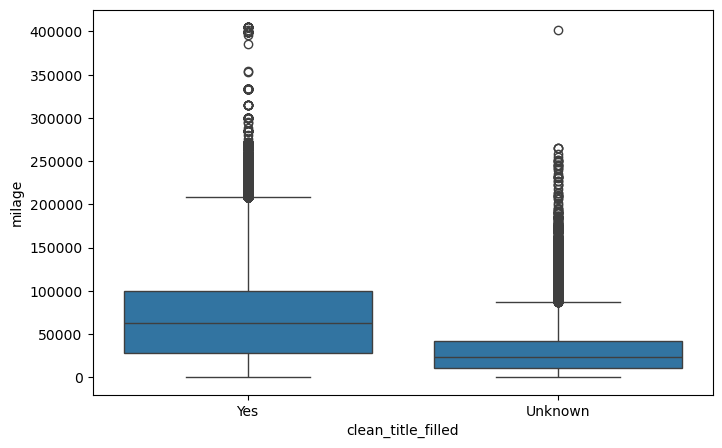

In [91]:
plt.figure(figsize=(8,5))
sns.boxplot(data=data, x='clean_title_filled', y='milage')
plt.show()

In [92]:
data.groupby('clean_title_filled')['price'].mean()

clean_title_filled
Unknown    63567.566273
Yes        41354.406704
Name: price, dtype: float64

In [93]:
data.isna().sum()

id                         0
brand                      0
model                      0
model_year                 0
milage                     0
fuel_type                  0
engine                     0
transmission               0
ext_col                    0
int_col                    0
accident                4084
clean_title            35658
price                 125690
is_gasoline                0
Electrical                 0
clean_title_filled         0
dtype: int64

In [ ]:
data[data['accident'].isna()][['accident', 'clean_title_filled']]

Series([], Name: count, dtype: int64)

In [110]:
data[data['price']==2954083.0]

,id,brand,model,model_year,milage,fuel_type,engine,transmission,ext_col,int_col,accident,clean_title,price,is_gasoline,Electrical,clean_title_filled
220,220,Ford,F-150 XLT,2021,26315,Gasoline,3.5L V6 24V PDI DOHC Twin Turbo,10-Speed Automatic,Agate Black Metallic,Black,None reported,Yes,2954083.0,1,0,Yes
1880,1880,Chrysler,300C Base,2003,55900,Gasoline,340.0HP 5.7L 8 Cylinder Engine Gasoline Fuel,5-Speed A/T,Beige,Beige,None reported,Yes,2954083.0,1,0,Yes
13838,13838,Toyota,Highlander SE,2014,85000,Gasoline,3.5L V6 24V PDI DOHC,8-Speed Automatic,Green,Black,None reported,Yes,2954083.0,1,0,Yes
14693,14693,Hyundai,Santa Fe SEL,2022,13865,Gasoline,2.5L I4 16V PDI DOHC,8-Speed Automatic,Black,Black,None reported,Yes,2954083.0,1,0,Yes
16034,16034,Mercedes-Benz,SL-Class SL500 Roadster,2005,34068,Gasoline,302.0HP 5.0L 8 Cylinder Engine Gasoline Fuel,7-Speed A/T,White,Beige,None reported,Yes,2954083.0,1,0,Yes
18946,18946,Audi,S4 Base,2004,73500,Gasoline,340.0HP 4.2L 8 Cylinder Engine Gasoline Fuel,6-Speed M/T,Blue,Beige,None reported,Yes,2954083.0,1,0,Yes
21814,21814,RAM,1500 Laramie,2022,16156,Gasoline,5.7L V8 16V MPFI OHV,8-Speed Automatic,Diamond Black,Black,None reported,NaN,2954083.0,1,0,Unknown
36615,36615,Ford,Excursion Limited Ultimate,2002,89900,Diesel,325.0HP 6.0L 8 Cylinder Engine Diesel Fuel,5-Speed A/T,Gold,Gold,None reported,Yes,2954083.0,0,0,Yes
42177,42177,Ford,Mustang GT,2005,82000,Gasoline,300.0HP 4.6L 8 Cylinder Engine Gasoline Fuel,5-Speed M/T,Silver,Black,None reported,Yes,2954083.0,1,0,Yes
42219,42219,Land,Rover Range Rover 3.0L V6 Supercharged HSE,2021,29850,Gasoline,380.0HP 3.0L V6 Cylinder Engine Gasoline Fuel,Transmission w/Dual Shift Mode,White,Black,None reported,Yes,2954083.0,1,0,Yes
